In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [5]:
df = pd.read_csv(r"C:\Users\sweth\Downloads\MaternalGuard\dataset\datasetmaternal_health.csv.csv")

In [6]:
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [7]:
df.shape

(1014, 7)

# Dataset Understanding

Features:

- Age
- SystolicBP
- DiastolicBP
- BS
- BodyTemp
- HeartRate
- RiskLevel

In [8]:
df.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

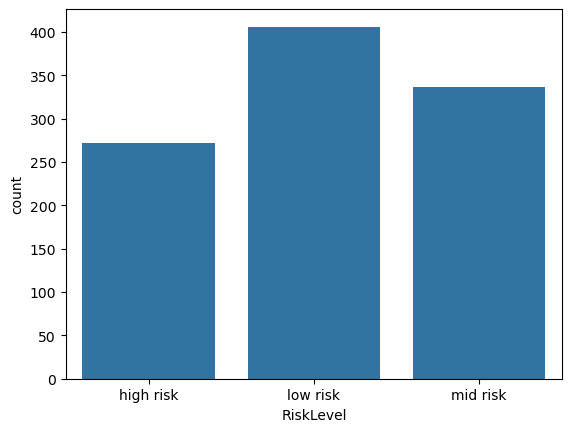

In [9]:
sns.countplot(x='RiskLevel',data=df)
plt.show()

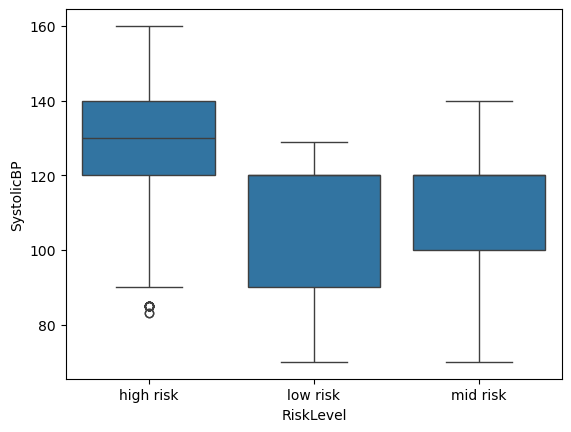

In [10]:
sns.boxplot(
x='RiskLevel',
y='SystolicBP',
data=df
)
plt.show()

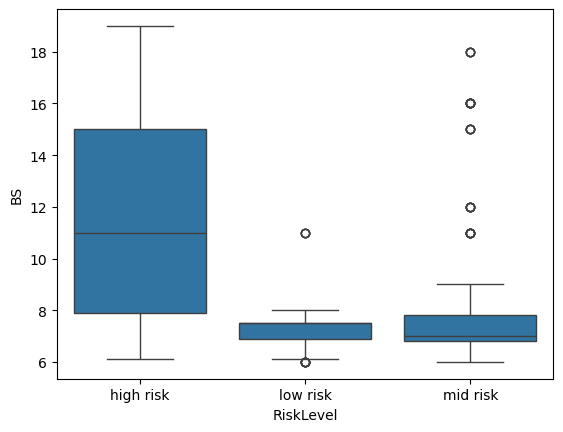

In [9]:
sns.boxplot(
x='RiskLevel',
y='BS',
data=df
)
plt.show()

In [11]:
mapping={
'low risk':0,
'mid risk':1,
'high risk':2
}

df['RiskLevel']=df['RiskLevel'].map(mapping)

In [13]:
X=df.drop("RiskLevel",axis=1)

y=df["RiskLevel"]

In [14]:
X_train,X_test,y_train,y_test=\
train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [15]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 2.5 MB/s eta 0:00:40
   - -------------------------------------- 3.7/101.7 MB 8.0 MB/s eta 0:00:13
   --- ------------------------------------ 8.1/101.7 MB 12.5 MB/s eta 0:00:08
   ---- ----------------------------------- 12.1/101.7 MB 13.6 MB/s eta 0:00:07
   ------ --------------------------------- 17.3/101.7 MB 16.0 MB/s eta 0:00:06
   -------- ------------------------------- 22.8/101.7 MB 17.6 MB/s eta 0:00:05
   ---------- ----------------------------- 26.5/101.7 MB 17.9 MB/s eta 0:00:05
   ----------- ---------------------------- 29.1/101.7 MB 16.9 MB/s eta 0:00:05
   ------------ --------------------------- 31.5/101.7 MB 16.3 MB/s eta 0:00:05
   ------------- -------------------------- 34.1/101.7 MB 16.1 MB/s eta 

In [16]:
from xgboost import XGBClassifier

model=XGBClassifier()

model.fit(
X_train,
y_train
)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [17]:
pred=model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score

accuracy_score(
y_test,
pred
)

0.8374384236453202

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [20]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.812807881773399


In [21]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.8177339901477833


In [22]:
from xgboost import XGBClassifier

In [23]:
xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.8374384236453202


In [24]:
print("Random Forest :", rf_acc)
print("Decision Tree :", dt_acc)
print("XGBoost       :", xgb_acc)

Random Forest : 0.812807881773399
Decision Tree : 0.8177339901477833
XGBoost       : 0.8374384236453202


In [25]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Random Forest', 'Decision Tree', 'XGBoost'],
    'Accuracy': [rf_acc, dt_acc, xgb_acc]
})

results

,Model,Accuracy
0,Random Forest,0.812808
1,Decision Tree,0.817734
2,XGBoost,0.837438


In [26]:
best_model = results.loc[results['Accuracy'].idxmax()]

print(best_model)

Model        XGBoost
Accuracy    0.837438
Name: 2, dtype: object


In [28]:
pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


In [29]:
import shap


In [30]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
xgb.fit(X_train, y_train)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [32]:
explainer = shap.TreeExplainer(rf)

In [33]:
shap_values = explainer.shap_values(X_test)

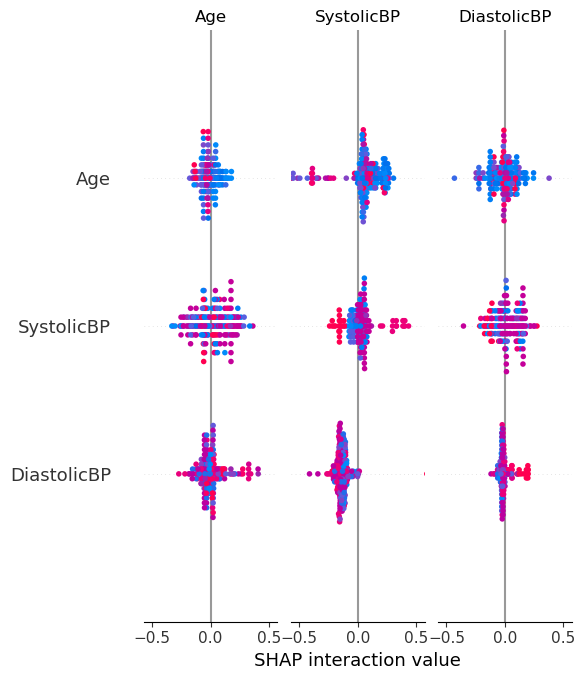

In [34]:
shap.summary_plot(
    shap_values,
    X_test
)

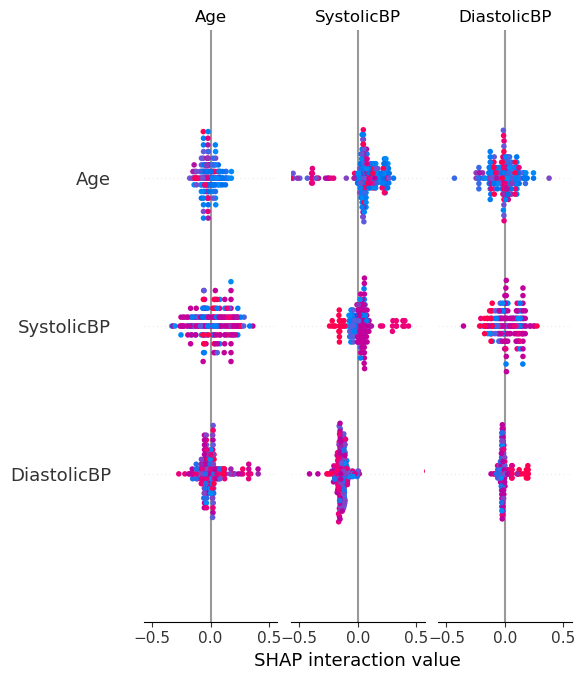

In [35]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.savefig(
    "feature_importance.png",
    bbox_inches="tight"
)

plt.show()

# Postpartum Wellness Module

In [36]:
sleep_hours = 6
mood_score = 7
stress_score = 4
water_intake = 2.5
activity_minutes = 30

In [37]:
sleep_score = min((sleep_hours / 8) * 100, 100)

print("Sleep Score:", sleep_score)

Sleep Score: 75.0


In [38]:
mood_percentage = (mood_score / 10) * 100

print("Mood Score:", mood_percentage)

Mood Score: 70.0


In [39]:
stress_percentage = ((10 - stress_score) / 10) * 100

print("Stress Wellness Score:", stress_percentage)

Stress Wellness Score: 60.0


In [40]:
recovery_score = (
    sleep_score +
    mood_percentage +
    stress_percentage
) / 3

print("Recovery Score:", round(recovery_score, 2))

Recovery Score: 68.33


In [41]:
if recovery_score >= 80:
    status = "Excellent Recovery"

elif recovery_score >= 60:
    status = "Moderate Recovery"

else:
    status = "Needs Attention"

print(status)

Moderate Recovery


In [42]:
if sleep_score < 70:
    print("Recommendation: Increase sleep duration.")

if stress_score > 6:
    print("Recommendation: Practice stress management.")

if mood_score < 5:
    print("Recommendation: Consider emotional support.")

In [43]:
postpartum_report = {
    "Sleep Score": sleep_score,
    "Mood Score": mood_percentage,
    "Stress Wellness": stress_percentage,
    "Recovery Score": recovery_score,
    "Status": status
}

postpartum_report

{'Sleep Score': 75.0,
 'Mood Score': 70.0,
 'Stress Wellness': 60.0,
 'Recovery Score': 68.33333333333333,
 'Status': 'Moderate Recovery'}